In [12]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Exploratory data analysis

### Global

In [13]:
global_df=pd.read_csv('../data/wgms-amce-2026-02-10/global.csv')
# missing data
print(global_df.isnull().sum())
# no missing values !

year                  0
area_km2              0
mwe                   0
mwe_sigma             0
mwe_cumsum            0
gt                    0
gt_sigma              0
gt_cumsum             0
gt_cumsum_sigma       0
mmsle                 0
mmsle_sigma           0
mmsle_cumsum          0
mmsle_cumsum_sigma    0
dtype: int64


**Descriptive statistics**

In [14]:
global_desc=pd.DataFrame(global_df[['area_km2','mwe','gt','mmsle']].describe())
global_desc

,area_km2,mwe,gt,mmsle
count,50.000000,50.000000,50.000000,50.000000
mean,704454.338200,-0.281960,-191.662640,0.528660
std,31915.163588,0.236843,157.031668,0.433176
min,651590.190000,-0.858000,-555.494000,-0.317000
25%,677088.022500,-0.442000,-301.434250,0.267000
50%,704205.970000,-0.252000,-180.000500,0.496500
75%,732916.122500,-0.128250,-96.789750,0.831750
max,754711.340000,0.159000,114.970000,1.532000


mwe, mmsle and gt have both postive and negative values, need to create visualizations taking care of that.

**Area variation over the years (km2)**

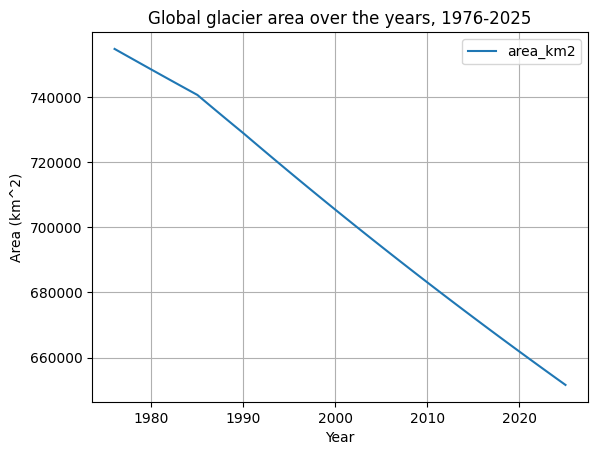

In [15]:
area_df = global_df.set_index('year')['area_km2']
area_df=pd.DataFrame(area_df)

area_df.plot()

plt.xlabel('Year')
plt.ylabel('Area (km^2)')
plt.title('Global glacier area over the years, 1976-2025')
plt.grid(True)


Very linear decrease, there seems to be a flex around the mid 80s: could look more into that. Does not seem very informative, apart from the fact that the decrease got steeper at some point. Look more closely at that time period.

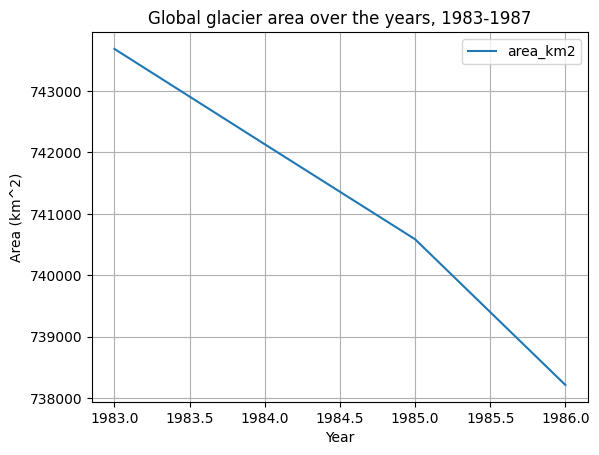

In [16]:

loc_area_df=area_df.reset_index()[area_df.reset_index()['year'].isin(range(1983,1987))]
loc_area_df.plot(x='year', y='area_km2')

plt.xlabel('Year')
plt.ylabel('Area (km^2)')
plt.title('Global glacier area over the years, 1983-1987')
plt.grid(True)
plt.show()

# 1985 seems to be the turning point

The flex coincides with the year 1985.

**Glacier mass change**

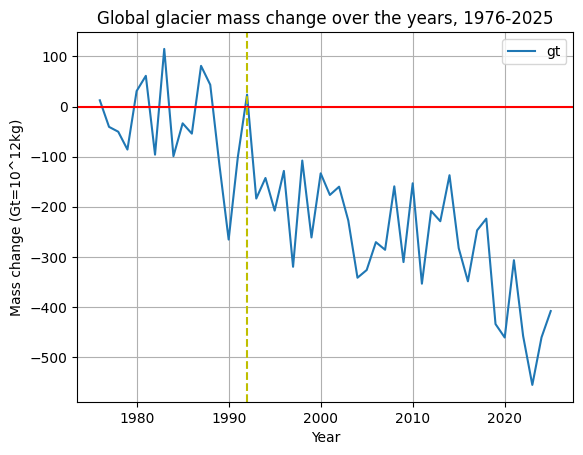

In [17]:
gt_df = global_df.set_index('year')['gt']
gt_df=pd.DataFrame(gt_df)

gt_df.plot()

plt.xlabel('Year')
plt.ylabel('Mass change (Gt=10^12kg)')
plt.title('Global glacier mass change over the years, 1976-2025')
plt.grid(True)

# insert a red horizontal line at mass=0
plt.axhline(y=0, color='r', linestyle='-')

# insert a yellow dashed vertical line at the year it stopped increasing


plt.axvline(x=1992, color='y', linestyle='--')

Website insight:

In [18]:
# average yearly mass loss between 2000 and 2019
avg_mass_loss_2000_2025 = gt_df[(gt_df.index >= 2000) & (gt_df.index <= 2025)]['gt'].mean()
print(f"Average yearly mass loss between 2000 and 2019: {avg_mass_loss_2000_2025:.2f} Gt/year")

Average yearly mass loss between 2000 and 2019: -294.53 Gt/year


As before, the decrease is definitely worse after some time in the '80s. The year 1985, found previously, is highlighted in yellow.

**Meters water equivalent**: area-average mass change expressed as the thickness of water that would be produced if the mass change were distributed evenly across the glacier area.

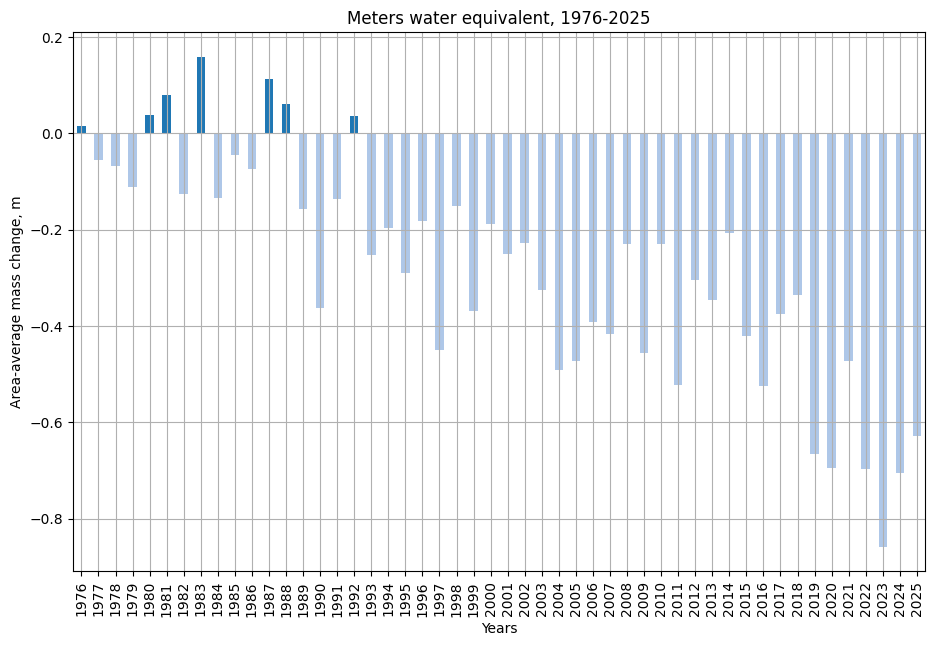

In [19]:
mwe_df = global_df.set_index('year')['mwe']

# split into positive and negative
mwe_pos=mwe_df.clip(lower=0)
mwe_neg=mwe_df.clip(upper=0)

fig, ax=plt.subplots(figsize=(11,7))
mwe_pos.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4'])
mwe_neg.plot(kind='bar', stacked=True, ax=ax,color=['#aec7e8'])

ax.set(title='Meters water equivalent, 1976-2025',
       xlabel='Years',
       ylabel='Area-average mass change, m')
plt.grid(True)

Quite a powerful visualization! 1992 is the last year reporting a positive change, and 2023 seems to be the worst one. Could work with this data in terms of 'known' quantities of water to make the audeìience understand better

**Millimeter sea level equivalent**: the change in global mean sea level that would occur if the glacier mass change were distributed evenly across the global ocean

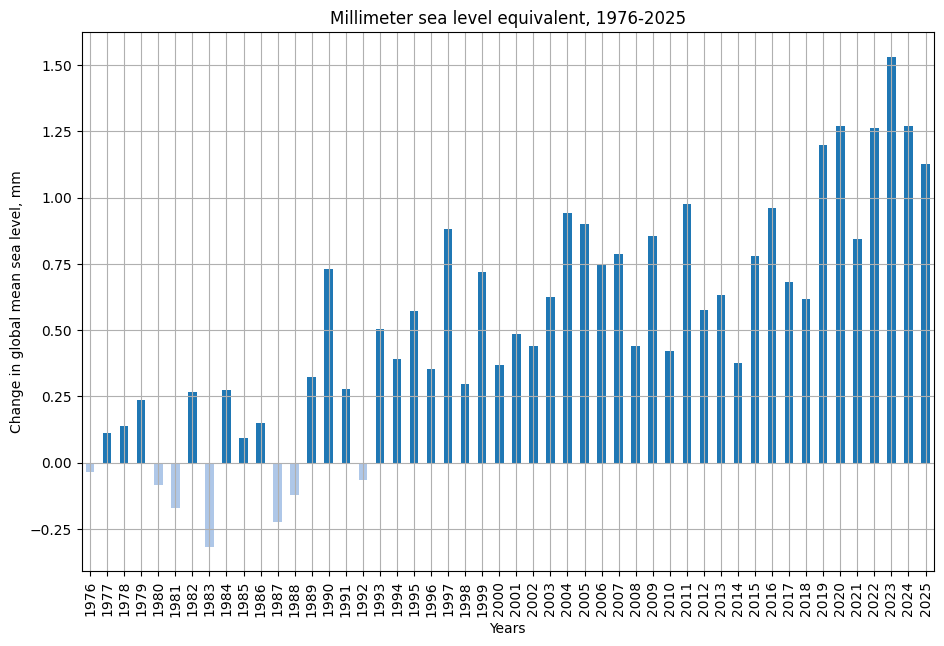

In [20]:
mmsle_df=global_df.set_index('year')['mmsle']

mmsle_pos=mmsle_df.clip(lower=0)
mmsle_neg=mmsle_df.clip(upper=0)

fig, ax=plt.subplots(figsize=(11,7))
mmsle_pos.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4'])
mmsle_neg.plot(kind='bar', stacked=True, ax=ax,color=['#aec7e8'])

ax.set(title='Millimeter sea level equivalent, 1976-2025',
       xlabel='Years',
       ylabel='Change in global mean sea level, mm')
plt.grid(True)
# 1992 was the last year witha a negative value (decrease in sea level)
# this is probably not the best graphic choice, not many negative values

In [22]:
mmsle_tot=mmsle_df.sum()
print(mmsle_tot)

26.433000000000003


Seems like inversely proportional to mwe (even for 1992). Might maybe use one of the two in our final del, maybe this one is an easier/more touching approach.

### Region: Central Europe

In [25]:
region_ceu_df=pd.read_csv('../data/wgms-amce-2026-02-10/region/CEU.csv')
print(region_ceu_df.isnull().sum())
# no missing values

year         0
area_km2     0
mwe          0
mwe_sigma    0
gt           0
gt_sigma     0
dtype: int64


**Descriptive statistics**

In [26]:
region_ceu_desc=pd.DataFrame(region_ceu_df[['area_km2','mwe','gt']].describe())
region_ceu_desc

,area_km2,mwe,gt
count,111.000000,111.000000,111.000000
mean,2547.980270,-0.238324,-0.431892
std,403.565293,0.781657,1.878371
min,1703.290000,-3.079000,-6.871000
25%,2202.340000,-0.639500,-1.645000
50%,2847.540000,-0.160000,-0.388000
75%,2874.270000,0.289500,0.777000
max,2874.270000,1.148000,3.217000


### Descriptive statistics for 1976-2025 (Central Europe)

In [27]:
region_ceu_restricted_df = region_ceu_df[ (region_ceu_df['year'] > 1976)]
region_ceu_restricted_desc = pd.DataFrame(region_ceu_restricted_df[['area_km2','mwe','gt','mwe','gt']].describe())
region_ceu_restricted_desc

,area_km2,mwe,gt,mwe,gt
count,49.000000,49.000000,49.000000,49.000000,49.000000
mean,2150.117347,-0.588633,-1.118347,-0.588633,-1.118347
std,286.554555,0.776281,1.581527,0.776281,1.581527
min,1703.290000,-3.079000,-5.394000,-3.079000,-5.394000
25%,1905.390000,-0.944000,-1.938000,-0.944000,-1.938000
50%,2131.460000,-0.483000,-1.065000,-0.483000,-1.065000
75%,2384.360000,-0.160000,-0.371000,-0.160000,-0.371000
max,2667.260000,1.148000,3.054000,1.148000,3.054000


More years than for the globa, starts at 1915. Compare this with the global results, taking the ratio with area_km2

**Glacier mass change**

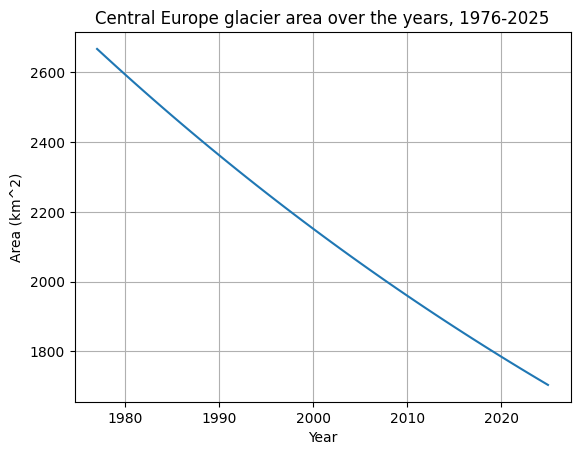

In [28]:
rea_df = region_ceu_restricted_df.set_index('year')['area_km2']
rea_df.plot(x='year', y='area_km2')

plt.xlabel('Year')
plt.ylabel('Area (km^2)')
plt.title('Central Europe glacier area over the years, 1976-2025')
plt.grid(True)
plt.show()

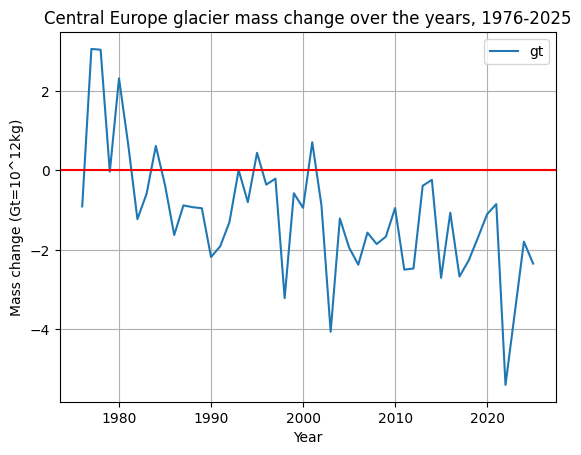

In [29]:
region_ceu_restricted_df = region_ceu_df[ (region_ceu_df['year'] >= 1976)]

gt_df = region_ceu_restricted_df.set_index('year')['gt']

gt_df=pd.DataFrame(gt_df)

gt_df.plot()

plt.xlabel('Year')
plt.ylabel('Mass change (Gt=10^12kg)')
plt.title('Central Europe glacier mass change over the years, 1976-2025')
plt.grid(True)

# insert a red horizontal line at mass=0
plt.axhline(y=0, color='r', linestyle='-')

This one shows much more oscillation than the global one, could overlap the two (maybe for just a period of time, would become chaotic).

**Meters water equivalent**

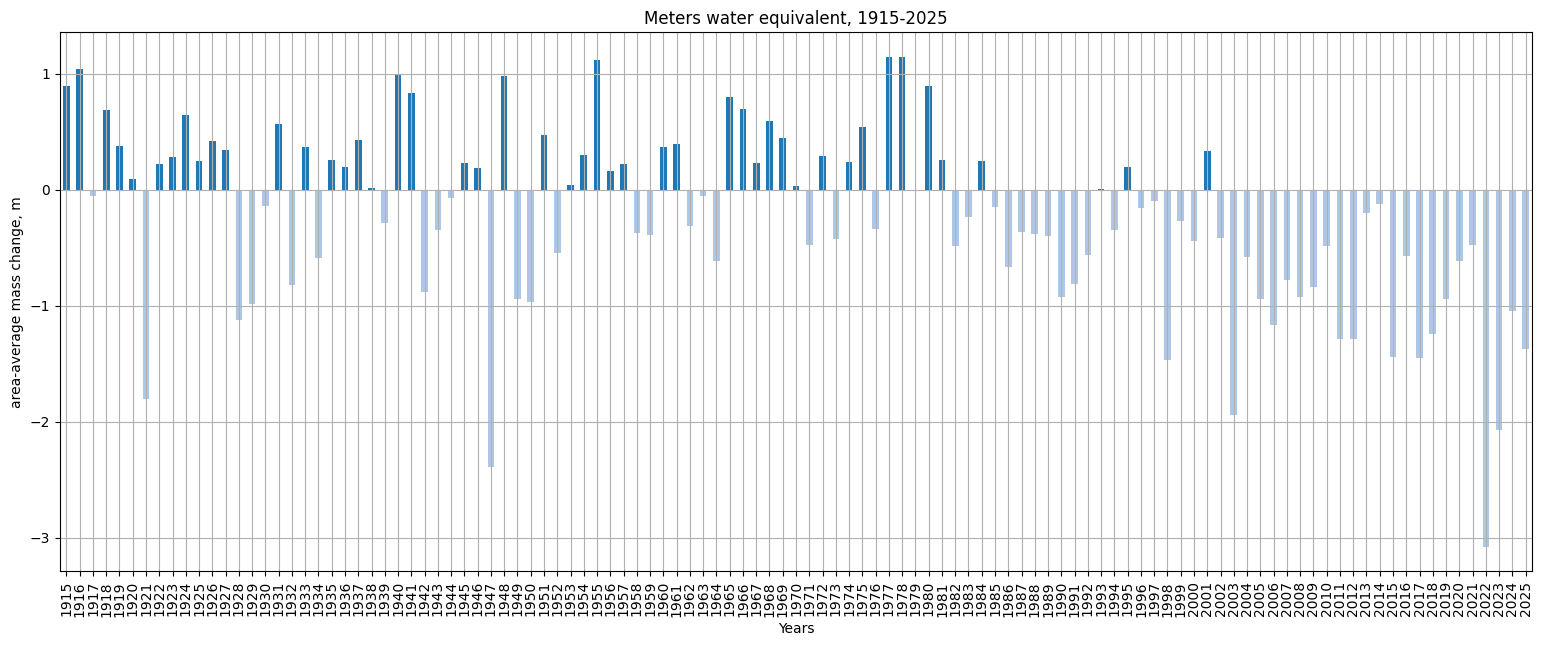

In [30]:
mwe_df = region_ceu_df.set_index('year')['mwe']

# restrict

mwe_pos=mwe_df.clip(lower=0)
mwe_neg=mwe_df.clip(upper=0)
# make the figsize adapt to the y values
fig, ax=plt.subplots(figsize=(19,7))
mwe_pos.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4'])
mwe_neg.plot(kind='bar', stacked=True, ax=ax,color=['#aec7e8'])

ax.set(title='Meters water equivalent, 1915-2025',
       xlabel='Years',
       ylabel='area-average mass change, m')
plt.grid(True)

### Glacier: Central Europe




In [31]:
glacier_ceu_df=pd.read_csv('../data/wgms-amce-2026-02-10/glacier/CEU_mwe.csv')
glacier_ceu_df.head()
# has a glacier per row, years on the columns

,outline_id,1915,1916,1917,1918,1919,1920,1921,1922,1923,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,RGI60-11.00001,0.698,0.847,-0.251,0.491,0.129,-0.083,-2.047,0.034,0.058,...,-1.029,-1.182,-1.746,-0.548,-1.307,-1.076,-2.604,-1.798,-1.487,-2.670
1,RGI60-11.00002,1.059,1.208,0.110,0.852,0.490,0.278,-1.685,0.396,0.420,...,-0.690,-0.754,-1.413,-0.114,-1.000,-0.788,-2.162,-1.357,-1.082,-2.425
2,RGI60-11.00003,0.789,0.938,-0.160,0.582,0.220,0.008,-1.956,0.125,0.149,...,-0.938,-1.091,-1.657,-0.455,-1.218,-0.985,-2.511,-1.705,-1.400,-2.582
3,RGI60-11.00004,1.207,1.356,0.258,1.000,0.638,0.427,-1.538,0.544,0.568,...,-0.517,-0.680,-1.236,-0.043,-0.794,-0.557,-2.101,-1.295,-0.989,-2.151
4,RGI60-11.00005,1.160,1.309,0.211,0.953,0.591,0.379,-1.585,0.496,0.520,...,-0.569,-0.717,-1.288,-0.080,-0.850,-0.617,-2.137,-1.331,-1.028,-2.218


Different structure from the other two, has all the glaciers of the region on the rows, years on the columns reporting the area-average mass change in km2

In [32]:
# missing data
print(glacier_ceu_df.isnull().sum())

outline_id    0
1915          0
1916          0
1917          0
1918          0
             ..
2021          0
2022          0
2023          0
2024          0
2025          0
Length: 112, dtype: int64


This dataset might make sense if we want to look at specific glaciers.